##1. Data Preparation

- **Import and Load Dataset**

In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
adityajn105_flickr8k_path = kagglehub.dataset_download('adityajn105/flickr8k')

print('Data source import complete.')


Using Colab cache for faster access to the 'flickr8k' dataset.
Data source import complete.


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/flickr8k/Images/2925242998_9e0db9b4a2.jpg
/kaggle/input/flickr8k/Images/2969380952_9f1eb7f93b.jpg
/kaggle/input/flickr8k/Images/444845904_a4531c811a.jpg
/kaggle/input/flickr8k/Images/3355827928_c96c0c3e88.jpg
/kaggle/input/flickr8k/Images/3150440350_b0f2a9e774.jpg
/kaggle/input/flickr8k/Images/3613705104_46d854134e.jpg
/kaggle/input/flickr8k/Images/3712742641_641282803e.jpg
/kaggle/input/flickr8k/Images/2922512807_d382528a93.jpg
/kaggle/input/flickr8k/Images/3323952123_deb50b0629.jpg
/kaggle/input/flickr8k/Images/3144705706_391d7b77c7.jpg
/kaggle/input/flickr8k/Images/3590653633_495de5f288.jpg
/kaggle/input/flickr8k/Images/421730441_6b2267fd31.jpg
/kaggle/input/flickr8k/Images/3647170476_0fd71a4c9f.jpg
/kaggle/input/flickr8k/Images/2432061076_0955d52854.jpg
/kaggle/input/flickr8k/Images/1798215547_ef7ad95be8.jpg
/kaggle/input/flickr8k/Images/1262077938_8b9516c273.jpg
/kaggle/input/flickr8k/Images/3480379024_545e8ec818.jpg

In [4]:
print(os.listdir('/kaggle/input/flickr8k'))
print(os.listdir(adityajn105_flickr8k_path))

['captions.txt', 'Images']
['captions.txt', 'Images']


- **Load and organize Flickr8k captions**

In [5]:
import csv
from collections import defaultdict

Image_Path = os.path.join(adityajn105_flickr8k_path, "Images")
Captions = os.path.join(adityajn105_flickr8k_path, "captions.txt")
#path for Images and Captions

def load_captions_csv(captions_file):
    captions_dict = defaultdict(list)

    with open(captions_file, 'r', encoding='utf-8') as file:
        reader = csv.reader(file) #reads CSV file

        # Skip header: ["image", "caption"]
        next(reader)

        for row in reader:
            if len(row) != 2:
                continue

            img_filename, caption = row
            img_filename = img_filename.strip()
            caption = caption.strip()

            captions_dict[img_filename].append(caption)
            #extract image and captions seperately and append in the dictionary

    return captions_dict

captions_dict = load_captions_csv(Captions)

print("Number of images with captions:", len(captions_dict))

# Show example
example_image = next(iter(captions_dict.keys()))
print("Example image:", example_image)
print("Captions:")
count = 0
for caption in captions_dict[example_image]:
    count += 1
    print(count, caption)


Number of images with captions: 8091
Example image: 1000268201_693b08cb0e.jpg
Captions:
1 A child in a pink dress is climbing up a set of stairs in an entry way .
2 A girl going into a wooden building .
3 A little girl climbing into a wooden playhouse .
4 A little girl climbing the stairs to her playhouse .
5 A little girl in a pink dress going into a wooden cabin .


- **Train and Validation Split**

In [6]:
import numpy as np

# All image filenames that have captions
files = sorted(list(captions_dict.keys()))

# Shuffle for randomness
np.random.seed(291)
np.random.shuffle(files)

# 80/20 split
split_ratio = 0.85
split_index = int(len(files) * split_ratio)

filenames_train = files[:split_index]
filenames_val   = files[split_index:]

# Map filenames → list of captions
captions_train = [captions_dict[file] for file in filenames_train]
captions_val   = [captions_dict[file] for file in filenames_val]

print("Train images:", len(filenames_train))
print("Val images:", len(filenames_val))




Train images: 6877
Val images: 1214


- **Helper Function**

A man in sunglasses sits on rocks .
A man sitting in clear shallow water beside a large rock face .
A person is sitting in a shallow lagoon .
Man with sunglasses sitting in shallow water .
The man with the white t-shirt is sitting in a stream looking at a rock .
Image path: /kaggle/input/flickr8k/Images/2676015068_690b0fb2cd.jpg


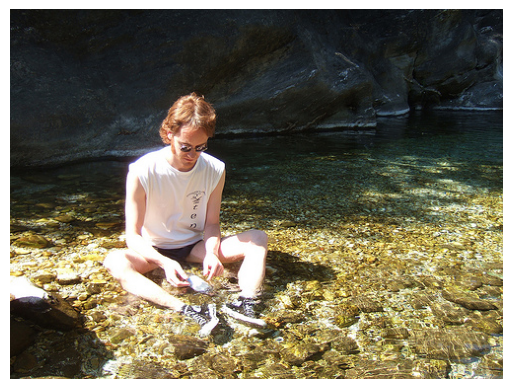

In [7]:
import matplotlib.pyplot as plt
import os
from PIL import Image

def show_image(idx, train=True):
    """
    Show an image and its captions, following the demo format.
    """
    if train:
        filename = filenames_train[idx]
        captions = captions_train[idx]
    else:
        filename = filenames_val[idx]
        captions = captions_val[idx]

    # Print captions (same as demo)
    for caption in captions:
        print(caption)

    # Load and display image
    path = os.path.join(Image_Path, filename)
    print(f"Image path: {path}") # Added line to print the image path
    img = Image.open(path).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.show()

show_image(idx=2210, train=True)

##2. VGG16 Feature Extraction (Encoder)

- **Import VGG16 and Build the Transfer Model**

In [8]:
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16

#Load the full VGG16 model
image_model = VGG16(include_top=True)

# Build a new model that outputs the fc2 features
transfer_layer = image_model.get_layer('fc2')
image_model_transfer = Model(inputs=image_model.input,
                             outputs=transfer_layer.output)

#Checking sizes
img_size = K.int_shape(image_model.input)[1:3]
transfer_values_size = K.int_shape(transfer_layer.output)[1]

print("Image size:", img_size)
print("Transfer vector size:", transfer_values_size)


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step
Image size: (224, 224)
Transfer vector size: 4096


- **Helper Function to Load and Preprocess Images**

In [9]:
def load_image(path, size=None):
    image = Image.open(path).convert("RGB")
    if size is not None:
        image = image.resize(size=size, resample=Image.LANCZOS)
    image = np.array(image).astype('float32') / 255.0
    return image

- **Batch Processing Function**

In [10]:
def process_images(data_dir, files, batch_size=32):
    total_images = len(files)

    # Pre-allocate arrays
    shape = (batch_size,) + img_size + (3,)
    image_batch = np.zeros(shape=shape, dtype=np.float32)

    transfer_values = np.zeros((total_images, transfer_values_size),
                               dtype=np.float32)

    start_index = 0

    while start_index < total_images:
        end_index = min(start_index + batch_size, total_images)
        current_batch_size = end_index - start_index

        # Load images into batch
        for i, filename in enumerate(filenames[start_index:end_index]):
            path = os.path.join(data_dir, filename)
            img = load_image(path, size=img_size)
            image_batch[i] = img

        # Extract VGG16 fc2 features
        transfer_values_batch = image_model_transfer.predict(
            image_batch[:current_batch_size], verbose=0
        )

        transfer_values[start_index:end_index] = transfer_values_batch
        start_index = end_index

    return transfer_values

- **Run Feature Extraction for Train and Validation Sets**

In [11]:
transfer_values_train = process_images(Image_Path, filenames_train, batch_size=32)
transfer_values_val   = process_images(Image_Path, filenames_val,   batch_size=32)

print("Train transfer shape:", transfer_values_train.shape)
print("Val transfer shape:", transfer_values_val.shape)


Train transfer shape: (6877, 4096)
Val transfer shape: (1214, 4096)


##3. Tokenization + Start/End Markers

- **Add Start/End Markers to Caption**

In [12]:
mark_start = 'start '
mark_end   = ' end'

def mark_captions(captions_listlist):
    return [
        [mark_start + caption + mark_end for caption in captions_list]
        for captions_list in captions_listlist
    ]

captions_train_marked = mark_captions(captions_train)
captions_val_marked   = mark_captions(captions_val)
print(captions_train_marked[0])
print(captions_val_marked[0])


['start A boy holds the bat waiting for the pitch at a baseball game . end', 'start A little boy batting in a baseball game . end', 'start A young boy in a blue and white uniform is up to bat at a baseball game . end', 'start Boy plays baseball . end', 'start Boy wearing a blue , white , and yellow baseball uniform about to hit a ball . end']
['start A man rides his skateboard with his shadow falling on a wall covered in graffiti . end', 'start A skateboarder grinding a lip . end', 'start A skateboarder is jumping through the air in front of a graffiti covered wall . end', 'start A skateboarder performs a skateboard trick against a graffiti wall . end', 'start A skateboarder performs tricks on a ramp in front of a wall with graffiti . end']


- **Flatten All Training Captions**

In [13]:
def flatten(captions_listlist):
    return [caption for captions_list in captions_listlist for caption in captions_list]

captions_train_flat = flatten(captions_train_marked)
print(captions_train_flat[0])

start A boy holds the bat waiting for the pitch at a baseball game . end


- **Build and Create the Tokenizer**

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

class TokenizerWrap(Tokenizer):
    def __init__(self, texts, total_words=None):
        super().__init__(num_words=total_words, oov_token=None)
        self.fit_on_texts(texts)
        self.index_to_word = dict(zip(self.word_index.values(),
                                      self.word_index.keys()))

    def token_to_word(self, token):
        return "" if token == 0 else self.index_to_word.get(token, "")

    def tokens_to_string(self, tokens):
        words = [self.index_to_word.get(text, "") for text in tokens if text != 0]
        return " ".join(words)

    def captions_to_tokens(self, captions_listlist):
        return [self.texts_to_sequences(captions_list)
                for captions_list in captions_listlist]

    print("Tokenizer is built")

tokenizer = TokenizerWrap(texts=captions_train_flat, total_words=5000)


Tokenizer is built


- **Extract Start/End Token ID**

In [15]:
token_start = tokenizer.word_index["start"]
token_end   = tokenizer.word_index["end"]

print("token_start:", token_start)
print("token_end:", token_end)

token_start: 3
token_end: 2


- **Convert All Captions to Token Sequences**

In [18]:
tokens_train = tokenizer.captions_to_tokens(captions_train_marked)
tokens_val   = tokenizer.captions_to_tokens(captions_val_marked)
print(tokens_train[0])
print(tokens_val[0])

[[3, 1, 16, 124, 5, 494, 370, 70, 5, 1461, 22, 1, 199, 164, 2], [3, 1, 40, 16, 2441, 4, 1, 199, 164, 2], [3, 1, 26, 16, 4, 1, 30, 8, 14, 198, 7, 52, 20, 494, 22, 1, 199, 164, 2], [3, 16, 114, 199, 2], [3, 16, 21, 1, 30, 14, 8, 56, 199, 198, 311, 20, 549, 1, 38, 2]]
[[3, 1, 11, 129, 29, 145, 10, 29, 901, 472, 6, 1, 110, 163, 4, 544, 2], [3, 1, 185, 997, 1, 4430, 2], [3, 1, 185, 7, 45, 33, 5, 64, 4, 48, 12, 1, 544, 163, 110, 2], [3, 1, 185, 443, 1, 145, 152, 254, 1, 544, 110, 2], [3, 1, 185, 443, 413, 6, 1, 186, 4, 48, 12, 1, 110, 10, 544, 2]]


## 4. LSTM Decoder Model

- **Model Hyperparameter**

In [ ]:
embedding_dimension = 256
state_size = 512

- **Inputs**

In [ ]:
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Dropout, Add
from tensorflow.keras.models import Model

# Image feature input (from VGG16)
input_image = Input(shape=(transfer_values_size,), name='input_image')

#Text input (token sequence)
input_caption = Input(shape=(None,), name='input_caption')

- **Image Feature Projection**

In [ ]:
initial_decoder = Dense(state_size, activation='tanh')(input_image)
#We reduce the 4096‑dim VGG16 vector to match the LSTM state size.
#initial_decoder becomes the initial hidden state of LSTM

- **Embedding Layer for Text**

In [ ]:
decoder_embedding = Embedding(input_dim=5000,
                              output_dim=embedding_dimension,
                              mask_zero=True,
                              name='decoder_embedding')(input_caption)

- **LSTM Decoder**

In [ ]:
LSTM_Decoder = LSTM(state_size,
                    return_sequences=True,
                    name='LSTM_Decoder')(decoder_embedding,
                                         initial_state=[initial_decoder, initial_decoder])

decoder_output = Dense(5000, activation='softmax', name='decoder_output')(LSTM_Decoder)



- **Build & Compile the model**

In [ ]:
model = Model(inputs=[input_image, input_caption],
              outputs=[decoder_output])

model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam')

## 5. Batch Generator + Training

- **Determine max caption length**

In [ ]:
max_tokens = max(len(tokens)
                 for captions in tokens_train
                 for tokens in captions)

print("Max caption length:", max_tokens)

- **Batch Generator**

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def batch_generator(file, tokens_listlist, batch_size):
    num_images = len(file)
    idx = 0

    while True:
        # Allocate batch arrays
        batch_input_images = np.zeros((batch_size, transfer_values_size))
        batch_input_tokens = np.zeros((batch_size, max_tokens))
        batch_output_tokens = np.zeros((batch_size, max_tokens, 1))

        for i in range(batch_size):
            # Wrap around dataset
            if idx >= num_images:
                idx = 0

            # Image feature
            batch_input_images[i] = transfer_values_train[idx]

            # Pick one of the 5 captions randomly
            tokens = tokens_listlist[idx][np.random.randint(5)]

            # Input and target sequences
            input_tokens = tokens[:-1]
            output_tokens = tokens[1:]

            # Pad
            input_tokens = pad_sequences([input_tokens], maxlen=max_tokens, padding='post')[0]
            output_tokens = pad_sequences([output_tokens], maxlen=max_tokens, padding='post')[0]

            batch_input_tokens[i] = input_tokens
            batch_output_tokens[i, :, 0] = output_tokens

            idx += 1

        # Change the list of inputs to a tuple of inputs
        yield (batch_input_images, batch_input_tokens), batch_output_tokens

- **Keras Sequence Wrapper**

In [ ]:
from tensorflow.keras.utils import Sequence

class DataGenerator(Sequence):
    def __init__(self, filenames, tokens_listlist, batch_size, **kwargs):
        super().__init__(**kwargs)
        self.filenames = filenames
        self.tokens_listlist = tokens_listlist
        self.batch_size = batch_size

    def __len__(self):
        return len(self.filenames) // self.batch_size

    def __getitem__(self, idx):
        return next(batch_generator(self.filenames, self.tokens_listlist, self.batch_size))

- **Create Generators**

In [ ]:
batch_size = 64

generator_train = DataGenerator(filenames_train, tokens_train, batch_size)
generator_val   = DataGenerator(filenames_val,   tokens_val,   batch_size)

- **Train the Model**

In [ ]:
steps_train = len(filenames_train) // batch_size
steps_val   = len(filenames_val)   // batch_size

history = model.fit(
    generator_train,
    validation_data=generator_val,
    epochs=20
)

##6. Caption Generation (Inference Mode)

- **Extract Transfer Values for a New Image**

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

def get_transfer_values(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    transfer_values = image_model_transfer.predict(img)
    return transfer_values[0]

- **Greedy Caption Generator**

In [ ]:
def generate_caption(image_path, max_len=max_tokens):
    # Extract VGG16 features
    transfer_values = get_transfer_values(image_path)
    transfer_values = np.expand_dims(transfer_values, axis=0)

    # Start with <start> token
    token_sequence = [token_start]
    caption_words = []

    for _ in range(max_len):
        # Pad sequence
        padded = pad_sequences([token_sequence], maxlen=max_len, padding='post')

        # Predict next token
        preds = model.predict([transfer_values, padded], verbose=0)
        next_token = np.argmax(preds[0, len(token_sequence)-1])

        # Stop if <end> token
        if next_token == token_end:
            break

        # Convert token → word
        word = tokenizer.index_to_word.get(next_token, "")
        caption_words.append(word)

        # Append token for next step
        token_sequence.append(next_token)

    return " ".join(caption_words)

img_path = "/kaggle/input/flickr8k/Images/2676015068_690b0fb2cd.jpg"   # change to your image
caption = generate_caption(img_path)
print("Generated Caption:", caption)


## 7. Evaluate the Model

- **Compute BLEU Scores**

In [ ]:
#Install NLTK tokenizer
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

#BLEU scoring function
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

def compute_bleu(model, tokenizer, filenames, tokens_listlist, num_samples=300):
    scores = []

    for i in range(num_samples):
        image_path = filenames[i]
        generated = generate_caption(img_path)

        # Prepare ground truth captions
        references = []
        for tokens in tokens_listlist[i]:
            caption = tokenizer.tokens_to_string(tokens)
            caption = caption.replace("start", "").replace("end", "").strip()
            references.append(nltk.word_tokenize(caption))

        candidate = nltk.word_tokenize(generated)

        score = sentence_bleu(references, candidate, smoothing_function=smooth)
        scores.append(score)

    return sum(scores) / len(scores)

#Run BLEU evaluation
bleu_score = compute_bleu(model, tokenizer, filenames_val, tokens_val, num_samples=300)
print("Average BLEU Score:", bleu_score)

- **Visualize Captions on Images**

In [ ]:
import matplotlib.pyplot as plt

def show_caption(image_path):
    # If only filename is provided, prepend the folder path
    if not image_path.startswith("/"):
        image_path = "/kaggle/input/flickr8k/Images/" + image_path

    caption = generate_caption(image_path)

    img = load_img(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(caption)
    plt.show()


##Test on 5 images
for i in range(5):
    show_caption(filenames_val[i])

- **Compare Generated Captions with Ground Truth**

In [ ]:
def compare_with_ground_truth(index):
    image_path = filenames_val[index]

    if not image_path.startswith("/"):
        image_path = "/kaggle/input/flickr8k/Images/" + image_path

    generated = generate_caption(image_path)

    print("Generated Caption:", generated)
    print("\nGround Truth Captions:")

    for tokens in tokens_val[index]:
        gt = tokenizer.tokens_to_string(tokens)
        gt = gt.replace("start", "").replace("end", "").strip()
        print("-", gt)

    show_caption(image_path)



In [ ]:
for i in range(5):
    show_caption(filenames_val[i])

## 8. Analyze the Results

- **Generate PDF with Image + Generated + Ground Truth**

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
from keras.utils import load_img

pdf = PdfPages("DL-PAUL-OUTPUT.pdf")

for i in range(5):
    image_path = filenames_val[i]
    if not image_path.startswith("/"):
        image_path = "/kaggle/input/flickr8k/Images/" + image_path

    generated = generate_caption(image_path)

    # Load image
    img = load_img(image_path)

    # Create figure
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")

    # Build ground truth text
    gt_text = ""
    for tokens in tokens_val[i]:
        gt = tokenizer.tokens_to_string(tokens)
        gt = gt.replace("start", "").replace("end", "").strip()
        gt_text += "- " + gt + "\n"

    plt.title(
        "Generated Caption:\n" + generated + "\n\n" +
        "Ground Truth Captions:\n" + gt_text,
        fontsize=10
    )

    pdf.savefig()
    plt.close()

pdf.close()